### Links

- https://fred.stlouisfed.org/release/tables?rid=18&eid=289#snid=324
- https://fred.stlouisfed.org/series/DGS10



In [1]:
from pathlib import Path
import pandas as pd
import re
import numpy as np
import matplotlib as plt

# Functions

**NS Code**

def ns_loadings(tau_years: np.ndarray, lam: float):
    tau = np.asarray(tau_years, float)
    x = lam * tau
    # Avoid division by zero at tau=0 (you generally won't include tau=0 anyway)
    L1 = (1.0 - np.exp(-x)) / x
    L2 = L1 - np.exp(-x)
    return L1, L2

def fit_ns_betas_for_date(tau_years, y, lam, w=None):
    """
    tau_years: array of maturities in years
    y: yields for that date (same length)
    lam: fixed lambda
    w: optional weights (same length)
    returns beta0, beta1, beta2
    """
    tau_years = np.asarray(tau_years, float)
    y = np.asarray(y, float)

    L1, L2 = ns_loadings(tau_years, lam)
    X = np.column_stack([np.ones_like(tau_years), L1, L2])

    if w is None:
        beta = np.linalg.lstsq(X, y, rcond=None)[0]
    else:
        w = np.asarray(w, float)
        ws = np.sqrt(w)
        beta = np.linalg.lstsq(X * ws[:, None], y * ws, rcond=None)[0]
    return beta

def extract_dns_factors(yields_df: pd.DataFrame, lam: float, weights=None) -> pd.DataFrame:
    """
    yields_df: index=dates, columns=maturities (years as floats/ints), values=yields
    weights: None, array-like per maturity, or dict maturity->weight
    """
    tau = np.array([float(c) for c in yields_df.columns], float)

    if isinstance(weights, dict):
        w = np.array([weights[float(c)] for c in yields_df.columns], float)
    elif weights is None:
        w = None
    else:
        w = np.asarray(weights, float)

    betas = []
    for dt, row in yields_df.iterrows():
        y = row.values.astype(float)
        mask = np.isfinite(y)
        if mask.sum() < 3:
            betas.append([np.nan, np.nan, np.nan])
            continue
        beta = fit_ns_betas_for_date(tau[mask], y[mask], lam, None if w is None else w[mask])
        betas.append(beta)

    factors = pd.DataFrame(betas, index=yields_df.index, columns=["beta0", "beta1", "beta2"])
    return factors.dropna()

**Maturity Mapping**

**Yields Generation <-- from model**

def ns_loadings(tau_years: np.ndarray, lam: float):
    tau = np.asarray(tau_years, dtype=float)
    x = lam * tau
    # safe for very small x
    L1 = np.where(x == 0.0, 1.0, (1.0 - np.exp(-x)) / x)
    L2 = L1 - np.exp(-x)
    return L1, L2

def ns_yield_curve_from_betas(tau_years, beta0, beta1, beta2, lam):
    tau_years = np.asarray(tau_years, dtype=float)
    L1, L2 = ns_loadings(tau_years, lam)
    y = beta0 + beta1 * L1 + beta2 * L2
    return pd.Series(y, index=tau_years)

def reconstruct_yields_from_factor_df(factors_df: pd.DataFrame, tau_years, lam: float) -> pd.DataFrame:
    """
    factors_df: index=dates, columns=['beta0','beta1','beta2']
    tau_years: list/array of maturities in years
    Returns: yields_hat_df with index=dates, columns=tau_years
    """
    tau_years = np.asarray(tau_years, float)
    L1, L2 = ns_loadings(tau_years, lam)

    # Shape: (T,1) + (T,1)*(N,) etc -> broadcasting to (T,N)
    b0 = factors_df["beta0"].to_numpy()[:, None]
    b1 = factors_df["beta1"].to_numpy()[:, None]
    b2 = factors_df["beta2"].to_numpy()[:, None]

    y_hat = b0 + b1 * L1[None, :] + b2 * L2[None, :]

    return pd.DataFrame(y_hat, index=factors_df.index, columns=tau_years)

**Plot Residuals**

In [2]:
def plot_residual_curve_on_date(yield_residuals: pd.DataFrame, date, in_bps=True):
    date = pd.to_datetime(date)

    # choose closest available date in the index
    nearest = yield_residuals.index[yield_residuals.index.get_indexer([date], method="nearest")[0]]

    row = yield_residuals.loc[nearest].dropna()
    if in_bps:
        row = 100 * row
        ylab = "Residual (bps)"
    else:
        ylab = "Residual (yield units)"

    mats = np.array(row.index, dtype=float)

    fig = go.Figure(go.Scatter(x=mats, y=row.to_numpy(), mode="lines+markers"))
    fig.update_layout(
        title=f"Yield Residual Curve on {nearest:%Y-%m-%d}",
        xaxis_title="Maturity (years)",
        yaxis_title=ylab,
    )
    fig.add_hline(y=0, line_color="black")
    fig.show()

In [3]:
def plot_signals(df, title):
    ax = df.plot(figsize=(12,6))
    ax.axhline(0, color="black")
    ax.set_title(title)
    plt.show()



In [4]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_signals2(x, title):
    # 1) Convert input to a DataFrame
    if isinstance(x, pd.Series):
        df = x.to_frame()
    elif isinstance(x, list):
        # If it's a list of Series/DataFrames, concat; otherwise make a DataFrame
        if len(x) > 0 and isinstance(x[0], (pd.Series, pd.DataFrame)):
            df = pd.concat(x, axis=1)
        else:
            df = pd.DataFrame(x)
    else:
        df = x.copy()

    # 2) Keep only numeric data (try coercion first)
    df = df.apply(pd.to_numeric, errors="coerce")

    # Drop columns that became all-NaN after coercion
    df = df.dropna(axis=1, how="all")

    if df.shape[1] == 0:
        raise ValueError(
            "After converting to numeric, there are no numeric columns to plot. "
            "Check your `signals` contents (maybe strings/dates/objects)."
        )

    # 3) Plot
    ax = df.plot(figsize=(12, 6))
    ax.axhline(0, color="black")
    ax.set_title(title)
    plt.show()

# Nelson–Siegel and Dynamic Nelson–Siegel Yield Curve Models

**1. Nelson–Siegel (NS) Model**

The **Nelson–Siegel model** provides a parsimonious representation of the yield curve using three latent factors.  
For a maturity \( \tau \), the yield at time \( t \) is given by:

$$
y_t(\tau) =
L_t
+ S_t \frac{1 - e^{-\lambda \tau}}{\lambda \tau}
+ C_t \left(\frac{1 - e^{-\lambda \tau}}{\lambda \tau} - e^{-\lambda \tau}\right)
$$

where:

- $L_t$ — **Level factor** (long-term interest rate component)
- $S_t$ — **Slope factor** (difference between short and long rates)
- $C_t$ — **Curvature factor** (medium-term hump in the yield curve)
- $\lambda$ — decay parameter controlling where the curvature loading peaks
- $\tau$ — maturity

**Interpretation of factors**

| Factor | Economic interpretation | Typical effect |
|------|------|------|
| Level | Long-run interest rate | Parallel shift of the curve |
| Slope | Short vs long rate spread | Steepening / flattening |
| Curvature | Medium-term hump | Changes around medium maturities |

In the **static Nelson–Siegel model**, the factors \(L_t, S_t, C_t\) are estimated **independently for each date** using cross-sectional regressions across maturities.

---

**2. Dynamic Nelson–Siegel (DNS)**

The **Dynamic Nelson–Siegel model** introduces time-series dynamics for the factors.

Let

$$
\beta_t =
\begin{bmatrix}
L_t \\
S_t \\
C_t
\end{bmatrix}
$$

The factor dynamics are typically modeled as:

$$
\beta_t = \mu + \Phi \beta_{t-1} + \varepsilon_t
$$

where:

- $( \Phi )$ is a **3×3 transition matrix**
- $( \mu )$ is a constant vector
- $( \varepsilon_t )$ is a vector of shocks

Thus:

**Dynamic Nelson–Siegel = Nelson–Siegel representation + VAR dynamics for the factors**

<u>Personal Notes:</u> DNS = VAR for the factors

---

**3. State-Space Representation**

DNS can also be written as a **state-space model**.

**Measurement equation (yields)**

$$
y_t(\tau) = \Lambda(\tau) \beta_t + \epsilon_t
$$

**State equation (factor dynamics)**

$$
\beta_t = \mu + \Phi \beta_{t-1} + \eta_t
$$

This representation allows estimation using the **Kalman filter**.

<u>Pers Note:</u>
    
    This means:
    
    - factors are not estimated independently
    - estimation uses all time-series information

---

**4. Two-Step (Diebold–Li) Estimation**

A common empirical implementation proceeds in two steps:

1. **Cross-sectional estimation**

Estimate $(L_t, S_t, C_t)$ for each time period using OLS.

2. **Time-series estimation**

Fit a VAR model to the factor series:

$$
\beta_t = \mu + \Phi \beta_{t-1} + u_t
$$

---

**5. Macro-Augmented DNS**

The model can be extended by allowing macroeconomic variables to influence the factor dynamics:

$$
\beta_t = \mu + \Phi \beta_{t-1} + \Gamma X_t + u_t
$$

where $(X_t)$ may include variables such as:

- inflation
- GDP growth
- output gap
- policy rate
- unemployment

This extension is often called a **macro-augmented Nelson–Siegel model** or a **macro-finance term structure model**.

---

**Key Takeaway**

- **NS model:** cross-sectional representation of the yield curve  
- **DNS model:** NS + time-series dynamics for factors  
- **Macro DNS:** DNS + macroeconomic drivers

**6. Macro-augmented Nelson–Siegel factor regressions**

A common **two-step macro-finance** approach is:

1. **Estimate Nelson–Siegel factors** $(L_t, S_t, C_t)$ at each time \(t\) using cross-sectional OLS across maturities.
2. **Relate the estimated factors to macroeconomic variables** via time-series regressions.

Let the factor vector be

$$
\beta_t =
\begin{bmatrix}
L_t \\
S_t \\
C_t
\end{bmatrix},
\qquad
X_t =
\begin{bmatrix}
\text{macro variables}
\end{bmatrix}.
$$

**(A) Separate regressions (one per factor)**

Regress each factor on the macro variables:

$$
L_t = \alpha_L + \gamma_L^\top X_t + \varepsilon_{L,t},
$$

$$
S_t = \alpha_S + \gamma_S^\top X_t + \varepsilon_{S,t},
$$

$$
C_t = \alpha_C + \gamma_C^\top X_t + \varepsilon_{C,t}.
$$

This setup is often described as **"macro regressions on Nelson–Siegel factors"** or **"macro-augmented Nelson–Siegel factor regressions."**

---

**(B) Vector form (system / multivariate regression)**

Equivalently, write the three regressions in compact form:

$$
\beta_t = a + \Gamma X_t + u_t,
$$

where

- $(a)$ is a $(3\times 1)$ intercept vector,
- $(\Gamma)$ is a $(3\times k)$ matrix of macro loadings,
- $(u_t)$ is a $(3\times 1)$ error vector.

---

**(C) Adding factor persistence (toward macro-augmented DNS)**

Because the factors are typically persistent, a common extension is to include lagged factors:

$$
\beta_t = \mu + \Phi \beta_{t-1} + \Gamma X_t + \eta_t.
$$

- If $(\Gamma=0)$, this reduces to the standard **Dynamic Nelson–Siegel (DNS)** VAR for the factors.
- If $(\Gamma \neq 0)$, this is often referred to as a **macro-augmented DNS** specification.

---

**Interpretation (typical macro linkages)**

Empirically, researchers often interpret:

- $(L_t)$ (level) as linked to long-run inflation / inflation expectations,
- $(S_t)$ (slope) as linked to monetary policy and the business cycle,
- $(C_t)$ (curvature) as capturing medium-maturity movements (hump) not explained by level/slope alone.

# Country-Agnostic DNS Pipeline: What to Change Per Country

Your DNS/NS code expects a DataFrame called `yields_df` with:
- **index**: dates (`DatetimeIndex`)
- **columns**: maturities in **years** as numbers (e.g. `0.25`, `1`, `2`, `5`, `10`)
- **values**: yields as floats (either decimals like `0.045` or percent like `4.5`, but consistent)

When you move from US to another country (Romania / Poland / Hungary / etc.), you typically adjust **only** these items:

---

**1. Column → Maturity Mapping *(required)***
You must map your raw column names to numeric maturities in **years**.

> **Example:** `"RO_2Y"` → `2.0`, `"PL_10Y"` → `10.0`, `"HUN_6M"` → `0.5`

---

**2. Unit Conversion *(required if needed)***
Many sources provide yields in **percent** (e.g. `7.25`) not decimals.
- If yields are in percent → set `convert_to_decimal=True` (divide by 100)
- If yields are already decimals → set `convert_to_decimal=False`

---

**3. Maturity Unit Check *(required)***
Ensure maturities are in **years**:

| Raw Tenor | Years |
|-----------|-------|
| 3M        | 0.25  |
| 6M        | 0.5   |
| 9M        | 0.75  |
| 1Y        | 1.0   |
| 2Y        | 2.0   |

> ⚠️ Do **not** mix months and years.

---

**4. Missing Data Policy *(often needed for EM)***
Emerging markets often have gaps or missing tenors. The factor extractor can handle `NaN`s per date as long as **≥ 3 maturities exist**. Your options:

- **a)** Leave `NaN`s *(recommended initially)*
- **b)** Drop dates with too many `NaN`s
- **c)** Light interpolation *(only if you're sure it's acceptable)*

---

**5. Weights *(optional but useful)***
If some tenors are illiquid/noisy, you can downweight them. `weights` can be:
- `None` *(default)*
- array-like aligned with columns
- `dict` maturity → weight
```python
weights = {1.0: 2.0, 2.0: 2.0, 10.0: 1.0, 30.0: 0.5}
```

---

**6. Lambda λ *(important for forecasting)***
For DNS forecasting, **fix λ across time**. You can:
- **a)** Use a standard λ as a starting point
- **b)** Tune λ **once** per country (or once globally) by out-of-sample RMSE, then freeze it

> 📌 **Note:** λ depends on maturities being in **years**.

---

**7. Data Frequency *(optional)***
Daily data is fine, but macro forecasting is often done on **monthly** data:
```python
yields_df = yields_df.resample("M").last()   # end-of-month
# or
yields_df = yields_df.resample("M").mean()   # monthly average
```

---

**✅ Minimum Checklist Per New Country**

| # | Task |
|---|------|
| ✅ | Column names → maturity in years (mapping) |
| ✅ | Percent vs. decimal conversion |
| ✅ | Ensure ≥ 3 maturities per date (or handle missing) |
| ✅ | Choose / fix λ — don't re-estimate daily for DNS |

# Country-Agnostic Nelson–Siegel / DNS Pipeline

This notebook is designed so the **same pipeline works for any country**  
(US, Romania, Poland, Hungary, etc.).

The model requires the yield data in a **specific format**.  
When switching to another country, only a few things need to be adjusted.

---

**Required Data Format**

The DNS functions expect a dataframe called **`yields_df`** with:

| Component | Requirement |
|---|---|
| Index | Dates (`DatetimeIndex`) |
| Columns | Maturities **in years** (numeric) |
| Values | Yields (floats, either decimals or percent) |

Example structure:

| Date | 1 | 2 | 3 | 5 | 7 | 10 | 20 | 30 |
|---|---|---|---|---|---|---|---|---|
| 1977-02-15 | 0.0539 | 0.0604 | 0.0635 | 0.0672 | 0.0714 | 0.0736 | 0.0762 | 0.0770 |

---

# What Must Be Adjusted For Each Country

**1. Column → Maturity Mapping (Required)**

Raw datasets usually have column names like:

    DGS10
    RO10Y
    PL_5Y
    HGBOND_3Y


These must be mapped to **maturity in years**.

Example:

```python
maturity_map = {
    "DGS1": 1.0,
    "DGS2": 2.0,
    "DGS5": 5.0,
    "DGS10": 10.0,
    "DGS30": 30.0
}
```
Romania example:
```python
maturity_map_ro = {
    "RO_6M": 0.5,
    "RO_1Y": 1.0,
    "RO_2Y": 2.0,
    "RO_5Y": 5.0,
    "RO_10Y": 10.0
}```

**2. Yield Units *(Required)***

Check whether yields are:

| Format  | Example  |
|---------|----------|
| Percent | `4.25`   |
| Decimal | `0.0425` |

If yields are in **percent**, convert them:
```python
yields_df = yields_df / 100
```

The model works with either format as long as it is **consistent**.

---

**3. Maturity Units *(Required)***

All maturities must be expressed in **years**.

| Tenor | Value |
|-------|-------|
| 3M    | 0.25  |
| 6M    | 0.5   |
| 1Y    | 1     |
| 2Y    | 2     |
| 5Y    | 5     |
| 10Y   | 10    |

> ⚠️ Do **not** mix months and years.

---

**4. Missing Data *(Important for Emerging Markets)***

Emerging market yield curves often have missing tenors.

The DNS estimation requires **at least 3 maturities per date**.

Possible strategies:

**Option A *(recommended initially)*** — Leave missing values:
```python
yields_df = yields_df.dropna(how="all")
```

**Option B** — Drop days with many missing values.

**Option C** — Small interpolation:
```python
yields_df = yields_df.interpolate(limit=3)
```

---

**5. Optional: Weights**

Some maturities may be illiquid. You can downweight them:
```python
weights = {
    1.0: 2.0,
    2.0: 2.0,
    10.0: 1.0,
    30.0: 0.5
}
```

> If no weights are provided, OLS is used.

---

**6. Lambda (λ) Choice**

In **Dynamic Nelson–Siegel (DNS)**, λ should be **fixed** across time.

**Option 1** — Use a standard value (good starting point).

**Option 2 *(recommended)*** — Tune λ once using out-of-sample forecasting error, then keep it fixed.

> λ depends on maturities being measured in **years**.

---

**7. Data Frequency**

Yield data can be **daily or monthly**. Many macro studies use **monthly data**.
```python
yields_df = yields_df.resample("M").last()   # end-of-month
# or
yields_df = yields_df.resample("M").mean()   # monthly average
```

---

**✅ Minimal Checklist When Adding a New Country**

Before running DNS estimation, verify:

| # | Check |
|---|-------|
| ✅ | Column names mapped to **maturity in years** |
| ✅ | Yields are **percent or decimal (consistent)** |
| ✅ | At least **3 maturities available** per date |
| ✅ | λ is **fixed** |
| ✅ | Data frequency is appropriate **(daily or monthly)** |

---

**Typical Pipeline**
```
Raw yield data
      ↓
Column → maturity mapping
      ↓
Prepare dataframe
      ↓
Estimate Nelson-Siegel factors
      ↓
Time-series model (VAR / AR)
      ↓
Forecast factors
      ↓
Reconstruct yield curve
```

> This pipeline works **identically for any country** once the input dataframe is standardized.

# Implementation

### Modules & Functions

In [9]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[0]
sys.path.append(str(PROJECT_ROOT))
data_folder = PROJECT_ROOT / "Data"

from src.data.data_loader import load_yield_curve_panel
from src.data.preprocessing import prepare_yield_dataframe
from src.models.ns import extract_dns_factors, reconstruct_yields_from_factor_df, ns_yield_curve_from_betas

In [10]:
maturity_map = {"DGS1": 1.0, "DGS2": 2.0, "DGS3": 3.0, "DGS5": 5.0, "DGS7": 7.0, "DGS10": 10.0, "DGS20": 20.0, "DGS30": 30.0}

In [11]:
yc = load_yield_curve_panel(data_folder)

yields_monthly = yc.resample("ME").mean()
yields_df = prepare_yield_dataframe(yields_monthly, maturity_map, convert_to_decimal=False)
maturities = yields_df.columns

<span style="color:red">Recheck if **last()** is better</span>

    yields_monthly = yields_df.resample("ME").mean()
    yields_monthly = yields_df.resample("ME").last()

In [12]:
yields_df.head(3)

,1.0,2.0,3.0,5.0,7.0,10.0,20.0,30.0
observation_date,,,,,,,,
1977-02-28,5.470000,6.082222,6.434444,6.854444,7.182222,7.411111,7.664444,7.754444
1977-03-31,5.500435,6.086522,6.469130,6.928261,7.201739,7.460000,7.734348,7.796087
1977-04-30,5.441000,5.963500,6.312500,6.792000,7.114000,7.370500,7.667500,7.734500


**maturities** is used to reconstruct model yields from forecasted factors

### Factors estimation

In [16]:
lam = 0.231
lam = 0.7

In [17]:
factors = extract_dns_factors(yields_df, lam=lam)
factors.head()

,beta0,beta1,beta2
observation_date,,,
1977-02-28,7.930172,-3.238297,-0.504058
1977-03-31,7.988851,-3.282112,-0.530740
1977-04-30,7.955873,-3.155122,-1.075622
1977-05-31,7.995971,-2.610858,-1.207317
1977-06-30,7.869068,-2.309821,-1.787732


### Factors Plot

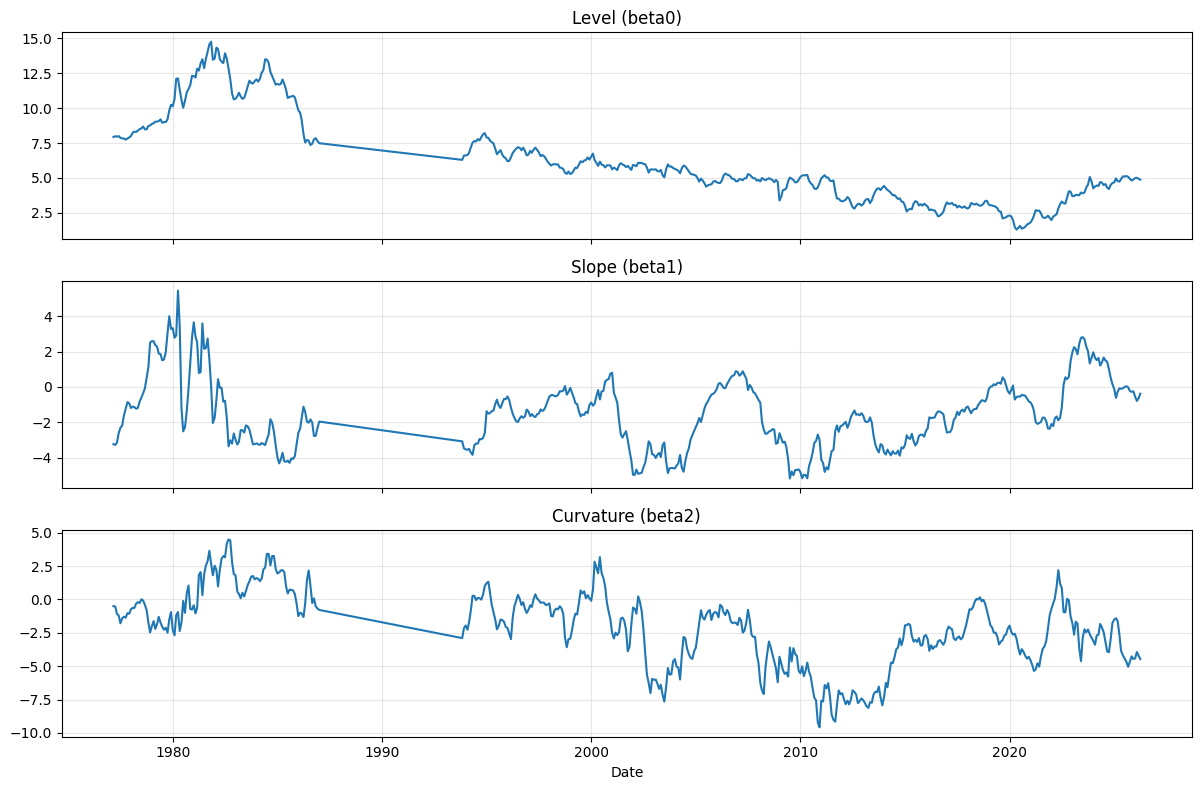

In [18]:
import matplotlib.pyplot as plt

# Ensure datetime index (safe even if already datetime)
factors = factors.copy()
factors.index = factors.index.to_datetime() if hasattr(factors.index, "to_datetime") else factors.index
# If the above line errors in your pandas version, use:
# factors.index = pd.to_datetime(factors.index)

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(12, 8), sharex=True)

cols = ["beta0", "beta1", "beta2"]
titles = ["Level (beta0)", "Slope (beta1)", "Curvature (beta2)"]

for ax, c, t in zip(axes, cols, titles):
    ax.plot(factors.index, factors[c])
    ax.set_title(t)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

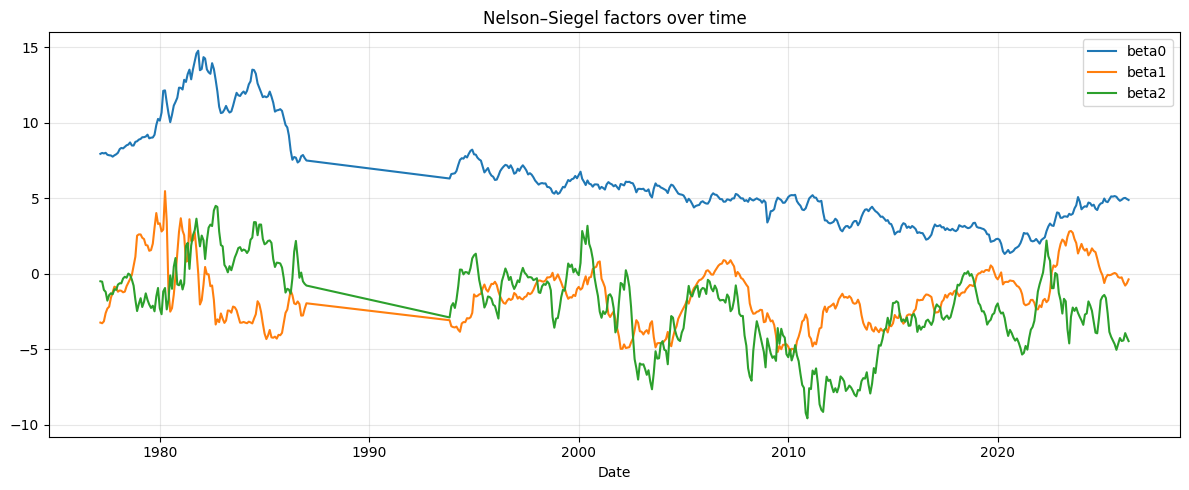

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))
for c in ["beta0", "beta1", "beta2"]:
    ax.plot(factors.index, factors[c], label=c)

ax.set_title("Nelson–Siegel factors over time")
ax.set_xlabel("Date")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

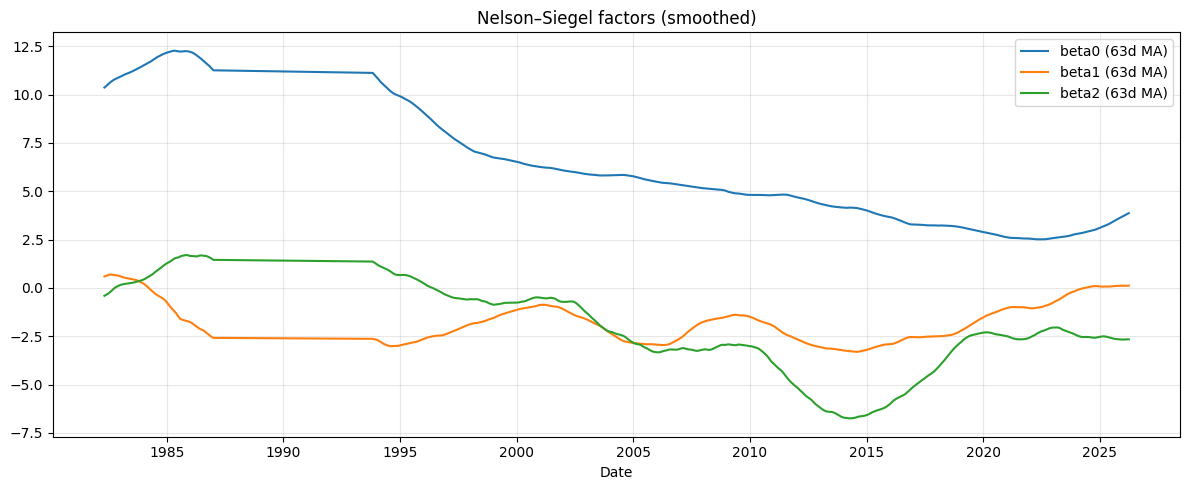

In [20]:
win = 63  # ~3 months of trading days
f_smooth = factors[["beta0","beta1","beta2"]].rolling(win).mean()

fig, ax = plt.subplots(figsize=(12, 5))
for c in f_smooth.columns:
    ax.plot(f_smooth.index, f_smooth[c], label=f"{c} ({win}d MA)")

ax.set_title("Nelson–Siegel factors (smoothed)")
ax.set_xlabel("Date")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

### YC Reconstruction

In [23]:
tau_grid = np.array([1, 2, 3, 5, 7, 10, 20, 30], float)
beta0, beta1, beta2 = factors.iloc[-1][["beta0","beta1","beta2"]]
print(factors.iloc[-1][["beta0","beta1","beta2"]])
yc_hat = ns_yield_curve_from_betas(tau_grid, beta0, beta1, beta2, lam=lam)
yc_hat

beta0    4.874712
beta1   -0.380024
beta2   -4.462615
Name: 2026-03-31 00:00:00, dtype: float64


1.0     3.608130
2.0     3.369137
3.0     3.397556
5.0     3.667641
7.0     3.927008
10.0    4.187606
20.0    4.528813
30.0    4.644110
dtype: float64

<span style="color:red">**YC Reconstruction**</span>

Reconstruction from **estimated factors**

In [24]:
tau_grid = np.array([1, 2, 3, 5, 7, 10, 20, 30], float)
yields_reconstructed_df = reconstruct_yields_from_factor_df(factors, tau_grid, lam=lam)
yields_reconstructed_df.head()

,1.0,2.0,3.0,5.0,7.0,10.0,20.0,30.0
observation_date,,,,,,,,
1977-02-28,5.489114,6.040542,6.428050,6.908437,7.175867,7.396497,7.662862,7.751965
1977-03-31,5.510343,6.067862,6.460536,6.948388,7.220464,7.445138,7.716505,7.807286
1977-04-30,5.447413,5.944364,6.319655,6.816072,7.106895,7.353013,7.653678,7.754409
1977-05-31,5.849614,6.238960,6.548284,6.974464,7.231545,7.452116,7.723245,7.814153
1977-06-30,5.810018,6.104840,6.375711,6.787676,7.052372,7.285867,7.576387,7.673947


### Comparison

In [25]:
'''
common_cols = sorted(set(yields_df.columns).intersection(set(yields_hat_df.columns)))
residuals = yields_df[common_cols].loc[yields_hat_df.index] - yields_hat_df[common_cols]

rmse_by_maturity = np.sqrt((residuals**2).mean())
rmse_by_maturity
'''

'\ncommon_cols = sorted(set(yields_df.columns).intersection(set(yields_hat_df.columns)))\nresiduals = yields_df[common_cols].loc[yields_hat_df.index] - yields_hat_df[common_cols]\n\nrmse_by_maturity = np.sqrt((residuals**2).mean())\nrmse_by_maturity\n'

### Plot actual vs reconstructed

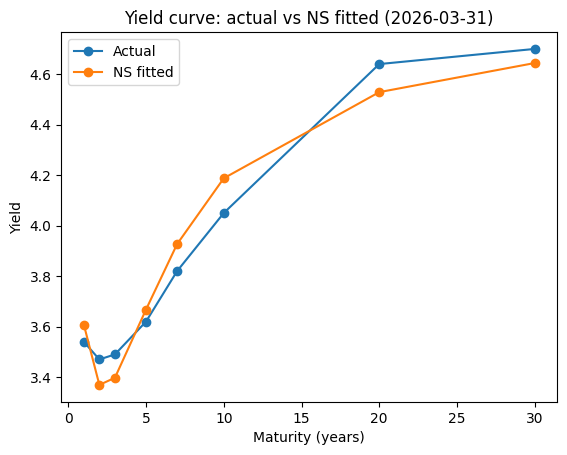

In [26]:
import matplotlib.pyplot as plt

date = yields_df.dropna().index[-1]
tau = np.array(sorted(yields_df.columns), float)

actual = yields_df.loc[date, tau].astype(float)
beta0, beta1, beta2 = factors.loc[date, ["beta0","beta1","beta2"]]
fitted = ns_yield_curve_from_betas(tau, beta0, beta1, beta2, lam=lam)

plt.figure()
plt.plot(tau, actual.values, marker="o", label="Actual")
plt.plot(tau, fitted.values, marker="o", label="NS fitted")
plt.xlabel("Maturity (years)")
plt.ylabel("Yield")
plt.legend()
plt.title(f"Yield curve: actual vs NS fitted ({date.date()})")
plt.show()

# Macro Variables

In [27]:
import os
from fredapi import Fred

#fred = Fred(api_key=os.getenv("FRED_API_KEY"))
fred = Fred(api_key = "FRED_API_KEY")

In [28]:
# Core macro variables
cpi = fred.get_series("CPIAUCSL")
unemployment = fred.get_series("UNRATE")
industrial_prod = fred.get_series("INDPRO")
fedfunds = fred.get_series("FEDFUNDS")
vix = fred.get_series("VIXCLS")

# Create main dataframe
macro_df = pd.concat([cpi, unemployment, industrial_prod, fedfunds, vix], axis=1)
macro_df.columns = ["CPI", "Unemployment", "IndustrialProduction", "FedFunds", "VIX"]

# Additional macro-finance variables
baa = fred.get_series("BAA")
gs10 = fred.get_series("GS10")

be5 = fred.get_series("T5YIE")
be10 = fred.get_series("T10YIE")

fwd_be = fred.get_series("T5YIFR")
hy_spread = fred.get_series("BAMLH0A0HYM2")

# Add financial variables
macro_df["CreditSpread"] = baa - gs10
macro_df["HighYieldSpread"] = hy_spread
macro_df["BE5Y"] = be5
macro_df["BE10Y"] = be10
macro_df["ForwardBE5Y5Y"] = fwd_be

# Convert everything to monthly frequency
macro_df = macro_df.resample("ME").mean()

In [29]:
# compute inflation measures
macro_df["Inflation_MoM"] = macro_df["CPI"].pct_change(fill_method=None) * 100
macro_df["Inflation_YoY"] = macro_df["CPI"].pct_change(12, fill_method=None) * 100
macro_df["Inflation_log_MoM"] = 100 * np.log(macro_df["CPI"]).diff() #For most macro time-series models (VAR, DSGE estimation, ML forecasting)
macro_df["Inflation_log_YoY"] = 100 * np.log(macro_df["CPI"]).diff(12)
macro_df["IP_growth"] = macro_df["IndustrialProduction"].pct_change(12, fill_method=None) * 100

In [30]:
macro_df.columns

Index(['CPI', 'Unemployment', 'IndustrialProduction', 'FedFunds', 'VIX',
       'CreditSpread', 'HighYieldSpread', 'BE5Y', 'BE10Y', 'ForwardBE5Y5Y',
       'Inflation_MoM', 'Inflation_YoY', 'Inflation_log_MoM',
       'Inflation_log_YoY', 'IP_growth'],
      dtype='object')

**Inspect Macro Variables**

In [31]:
#plt.plot(macro_df[['CreditSpread', 'HighYieldSpread']])
#plt.plot(macro_df['CreditSpread'])

# Model Setup

In [32]:
data = factors.rename(columns={'beta0': 'level', 'beta1': 'slope', 'beta2': 'curvature'}).join(macro_df, how="inner")

**Period Filtering**

In [33]:
mask_filter = (data.index.year >= 2000) & (data.index.year != 2020)
data_filtered = data.loc[mask_filter]

# Factor Regression

In [34]:
macro_cols = ["Unemployment", "FedFunds", "HighYieldSpread"]

reg_cols = macro_cols.copy()
reg_cols = ["level", "slope", "curvature"] + macro_cols

reg_data = data_filtered[reg_cols].replace([np.inf, -np.inf], np.nan).dropna()

In [35]:
#reg_data.isna().sum()

In [36]:
import statsmodels.api as sm

X = reg_data[macro_cols]
X = sm.add_constant(X)

level_model = sm.OLS(reg_data["level"], X).fit()
slope_model = sm.OLS(reg_data["slope"], X).fit()
curv_model = sm.OLS(reg_data["curvature"], X).fit()

In [37]:
print(level_model.summary())
print(slope_model.summary())
print(curv_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  level   R-squared:                       0.511
Model:                            OLS   Adj. R-squared:                  0.506
Method:                 Least Squares   F-statistic:                     103.2
Date:                Thu, 05 Mar 2026   Prob (F-statistic):           9.66e-46
Time:                        13:46:18   Log-Likelihood:                -358.33
No. Observations:                 300   AIC:                             724.7
Df Residuals:                     296   BIC:                             739.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.8304      0.232     

In [38]:
# parameters
level_model.params
#slope_model.params
#curv_model.params

const              0.830434
Unemployment       0.356051
FedFunds           0.486028
HighYieldSpread    0.080329
dtype: float64

In [39]:
level_model.pvalues
#slope_model.pvalues
#curv_model.pvalues

const              4.089854e-04
Unemployment       2.411393e-20
FedFunds           1.050381e-44
HighYieldSpread    5.373546e-05
dtype: float64

In [40]:
level_model.rsquared
#slope_model.rsquared
#curv_model.rsquared

np.float64(0.5112046139923396)

In [41]:
# Get predicted factors
reg_data["level_pred"] = level_model.predict(X)
reg_data["slope_pred"] = slope_model.predict(X)
reg_data["curv_pred"] = curv_model.predict(X)

In [42]:
# Compute missing signals
reg_data["level_signal"] = reg_data["level"] - reg_data["level_pred"]
reg_data["slope_signal"] = reg_data["slope"] - reg_data["slope_pred"]
reg_data["curv_signal"] = reg_data["curvature"] - reg_data["curv_pred"]

## Plot Results

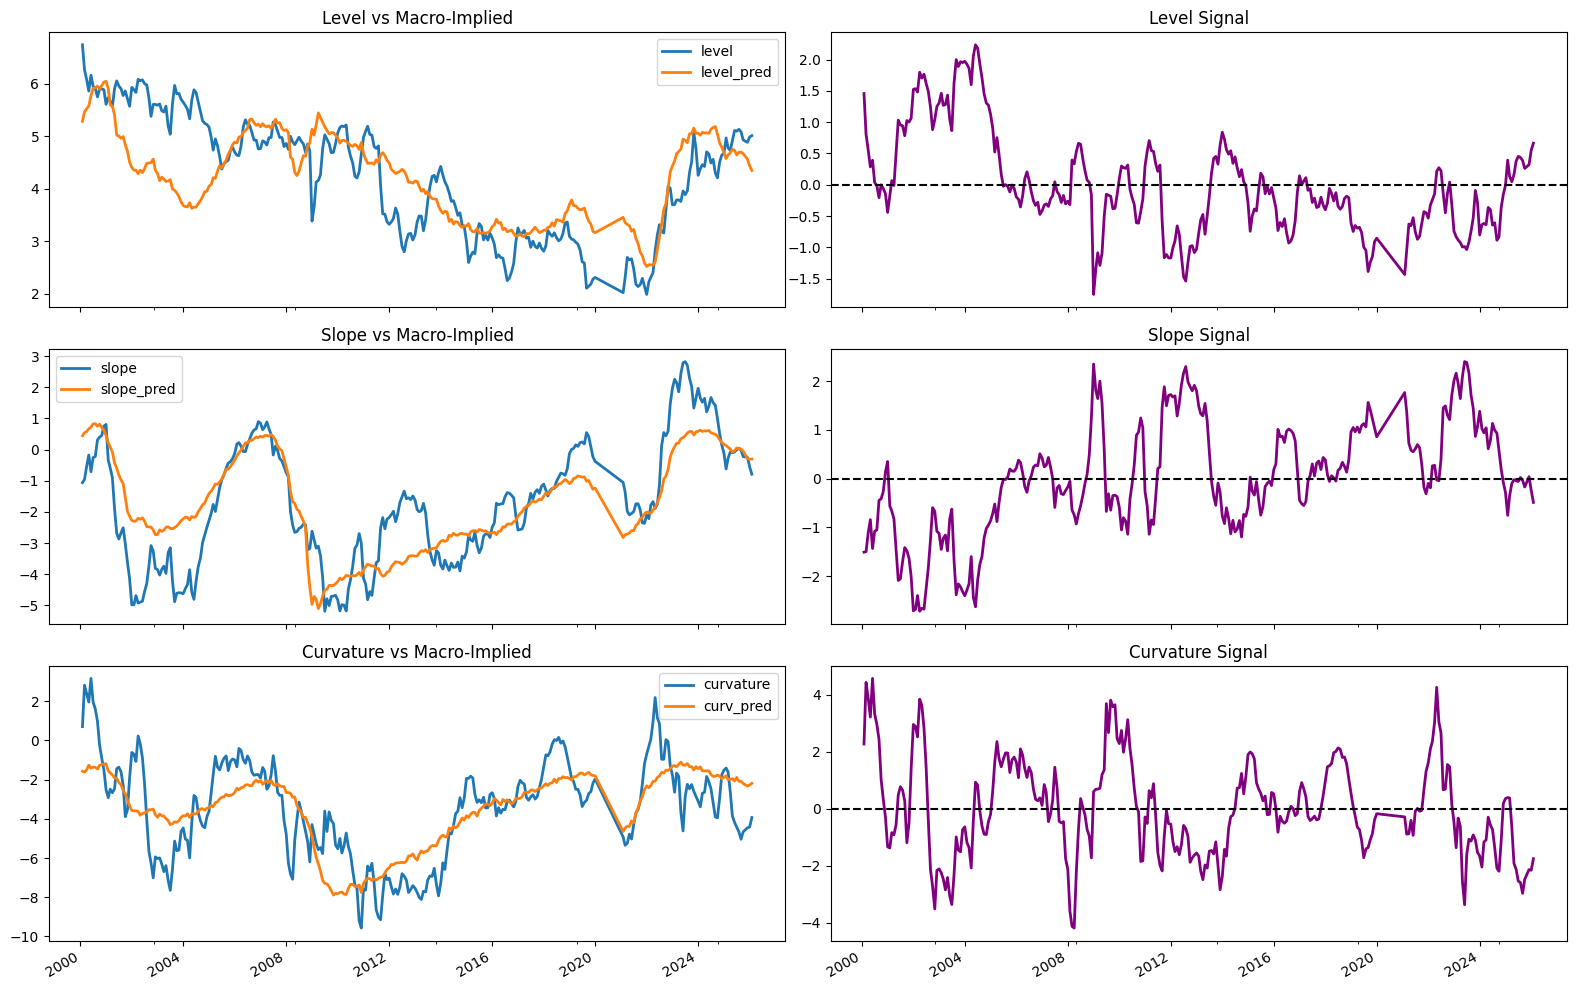

In [43]:
factors = ["level","slope","curvature"]
preds = ["level_pred","slope_pred","curv_pred"]
signals = ["level_signal","slope_signal","curv_signal"]

fig, ax = plt.subplots(3,2, figsize=(16,10), sharex=True)

for i in range(3):
    reg_data[[factors[i], preds[i]]].plot(ax=ax[i,0], lw=2)
    ax[i,0].set_title(f"{factors[i].capitalize()} vs Macro-Implied")

    reg_data[signals[i]].plot(ax=ax[i,1], color="purple", lw=2)
    ax[i,1].axhline(0, linestyle="--", color="black")
    ax[i,1].set_title(f"{factors[i].capitalize()} Signal")

plt.tight_layout()
plt.show()

## Impled Yields reconstruction

In [44]:
# Predicted factors
predicted_factors = reg_data[["level_pred","slope_pred","curv_pred"]].copy()
predicted_factors.rename(columns={"level_pred": "beta0", "slope_pred": "beta1", "curv_pred": "beta2"}, inplace=True)

In [45]:
predicted_factors.head()

,beta0,beta1,beta2
2000-01-31,5.287806,0.447167,-1.571204
2000-02-29,5.468985,0.541394,-1.620246
2000-03-31,5.529162,0.577232,-1.492236
2000-04-30,5.578817,0.667099,-1.262518
2000-05-31,5.775798,0.723567,-1.412296


Reconstruction from **regressed/predicted factors**

In [46]:
tau_maturities = np.array(maturities)
y_model = reconstruct_yields_from_factor_df(predicted_factors, tau_maturities, lam=lam)
#y_model.head() #model yields

In [47]:
y_market = yields_df[mask_filter].copy()
y_market.head() #market yields

,1.0,2.0,3.0,5.0,7.0,10.0,20.0,30.0
observation_date,,,,,,,,
2000-01-31,6.121500,6.440000,6.489000,6.579500,6.702500,6.661000,6.862500,6.625500
2000-02-29,6.218000,6.610500,6.652500,6.678000,6.716500,6.519500,6.539000,6.232000
2000-03-31,6.222174,6.528261,6.528261,6.503913,6.506522,6.256522,6.380435,6.053478
2000-04-30,6.150526,6.403684,6.356316,6.262632,6.265789,5.990526,6.184737,5.846316
2000-05-31,6.326364,6.809545,6.767727,6.687727,6.689545,6.440455,6.548182,6.148636


**Allign indices**

In [48]:
common_dates = y_model.index.intersection(y_market.index)

y_model = y_model.loc[common_dates]
y_market = y_market.loc[common_dates]
yield_residuals = (y_market - y_model)*100

In [49]:
yield_residuals.head()

,1.0,2.0,3.0,5.0,7.0,10.0,20.0,30.0
2000-01-31,86.182424,136.963499,147.850036,155.570335,163.068117,153.219172,165.498118,139.121977
2000-02-29,72.029606,132.254604,143.593376,145.902296,145.398390,120.301856,114.707431,81.438877
2000-03-31,61.002682,112.352246,119.872457,118.322437,115.159243,85.659448,91.662880,56.788778
2000-04-30,37.296586,83.395640,87.170825,81.067281,79.818065,49.554073,64.844906,29.585245
2000-05-31,34.454864,105.611515,110.678873,106.011871,104.274056,76.166847,82.157718,40.563463


## Signals

In [50]:
signal_10y = yield_residuals[10.0]
curve_signal = yield_residuals[10.0] - yield_residuals[2.0]
fly_signal = yield_residuals[5.0] - 0.5*(yield_residuals[2.0] + yield_residuals[10.0])

In [51]:
#plt.plot(signal_10y)

In [52]:
#plt.plot(curve_signal)

In [53]:
signals = pd.DataFrame({
    "10Y_signal": yield_residuals[10.0],
    "2s10s_signal": yield_residuals[10.0] - yield_residuals[2.0],
    "10s30s_signal": yield_residuals[30.0] - yield_residuals[10.0],
    "fly_signal": yield_residuals[5.0] - 0.5*(yield_residuals[2.0] + yield_residuals[10.0]),
})

In [54]:
#plt.plot(yield_residuals)

In [55]:
signals_z = (signals - signals.rolling(60).mean()) / signals.rolling(60).std()

## Signals Plots

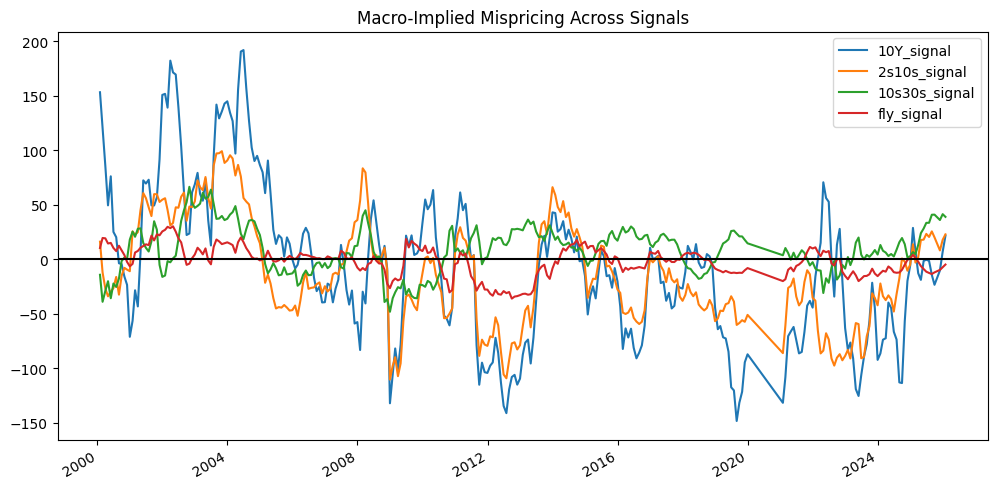

In [56]:
plot_signals(signals, "Macro-Implied Mispricing Across Signals")

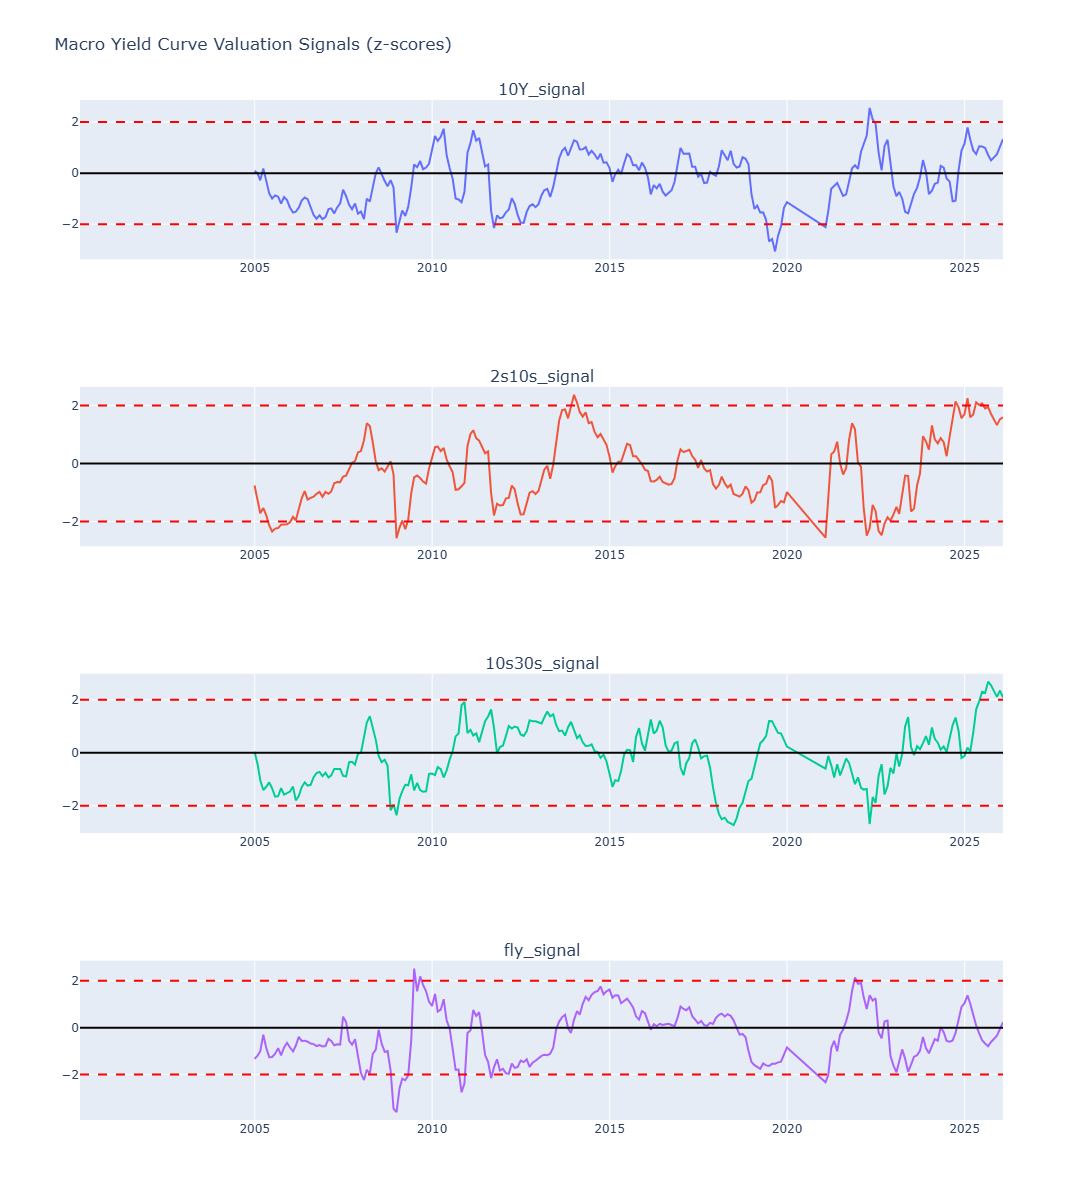

In [57]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# number of signals
n = len(signals_z.columns)

# create stacked subplots
fig = make_subplots(
    rows=n,
    cols=1,
    shared_xaxes=False,
    subplot_titles=signals_z.columns
)

for i, col in enumerate(signals_z.columns):

    # main signal line
    fig.add_trace(
        go.Scatter(
            x=signals_z.index,
            y=signals_z[col],
            mode='lines',
            name=col
        ),
        row=i+1,
        col=1
    )

    # horizontal lines
    fig.add_hline(y=0, line_color="black", row=i+1, col=1)
    fig.add_hline(y=2, line_dash="dash", line_color="red", row=i+1, col=1)
    fig.add_hline(y=-2, line_dash="dash", line_color="red", row=i+1, col=1)

# layout
fig.update_layout(
    height=300*n,
    width=900,
    title="Macro Yield Curve Valuation Signals (z-scores)",
    showlegend=False
)



fig.show()

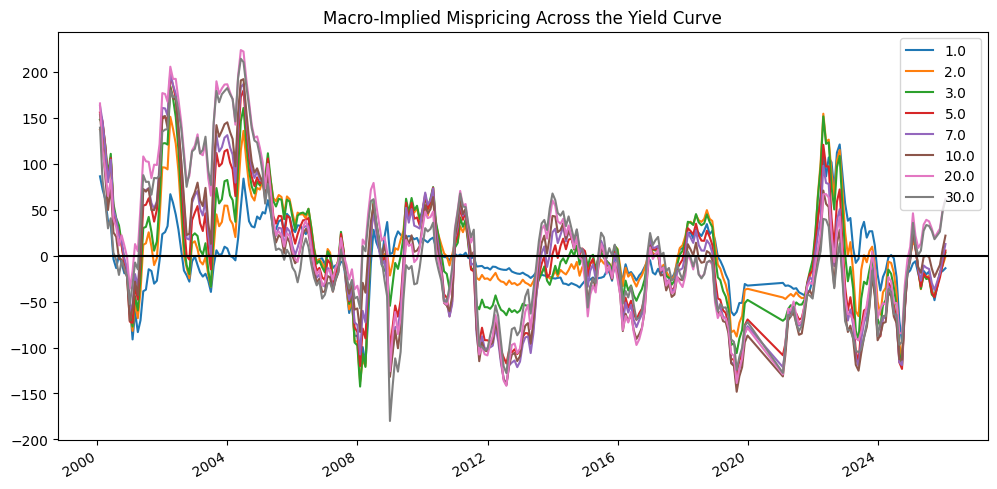

In [58]:
plot_signals(yield_residuals, "Macro-Implied Mispricing Across the Yield Curve")

In [59]:
yield_residuals[10.0].autocorr()

np.float64(0.936747375257861)

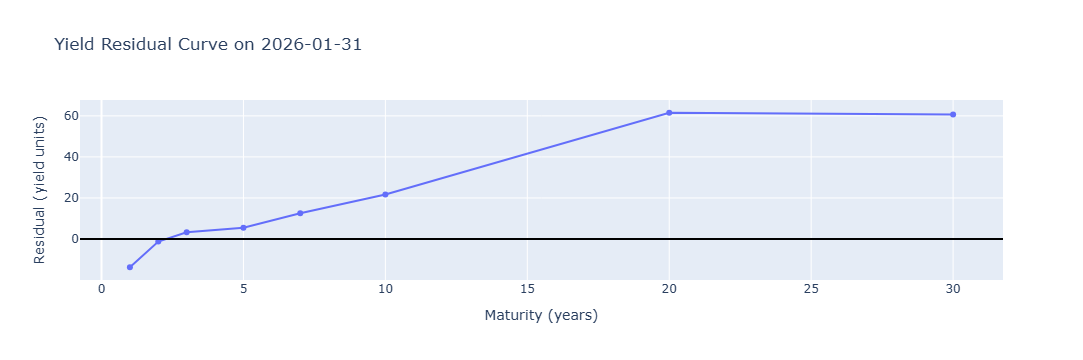

In [60]:
plot_residual_curve_on_date(yield_residuals, "2026-01-28", in_bps=False)

## Residual Diagnostics

In [61]:
from statsmodels.stats.diagnostic import acorr_ljungbox
import pandas as pd

def autocorr_table(df, lags=12):
    rows = []
    
    for col in df.columns:
        x = df[col].dropna()
        
        lb = acorr_ljungbox(x, lags=[lags], return_df=True)
        phi = x.autocorr(1)
        
        rows.append({
            "maturity": col,
            "AR1": phi,
            "LjungBox_p": lb["lb_pvalue"].iloc[0]
        })
        
    return pd.DataFrame(rows)

autocorr_results = autocorr_table(yield_residuals)
print(autocorr_results)

   maturity       AR1     LjungBox_p
0       1.0  0.912929  6.865125e-165
1       2.0  0.915158  2.907095e-154
2       3.0  0.919551  4.187520e-173
3       5.0  0.929414  3.459244e-224
4       7.0  0.934880  1.305104e-256
5      10.0  0.936747  6.344370e-279
6      20.0  0.952647   0.000000e+00
7      30.0  0.951618   0.000000e+00


In [62]:
import numpy as np

def half_life(phi):
    if phi <= 0 or phi >= 1:
        return np.nan
    return np.log(0.5) / np.log(phi)

hl = yield_residuals.apply(lambda x: half_life(x.autocorr(1)))
print(hl)

1.0      7.608913
2.0      7.818212
3.0      8.264527
5.0      9.469060
7.0     10.293681
10.0    10.608046
20.0    14.288526
30.0    13.977163
dtype: float64


<Axes: >

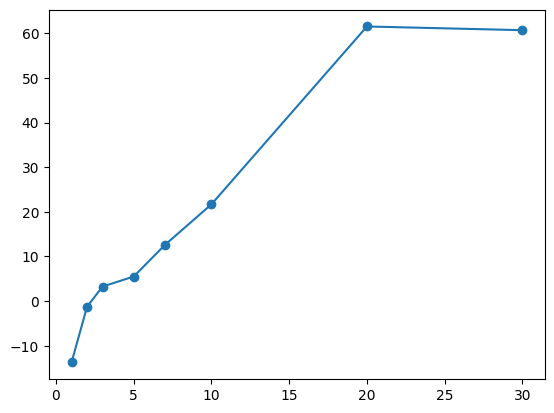

In [63]:
yield_residuals.iloc[-1].plot(marker='o')

In [64]:
z_scores = (
    yield_residuals
    .rolling(60)
    .apply(lambda x: (x.iloc[-1] - x.mean()) / x.std())
)

In [65]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
pca_factors = pca.fit_transform(yield_residuals.dropna())

print(pca.explained_variance_ratio_)

[0.88565983 0.09853604 0.01002078]


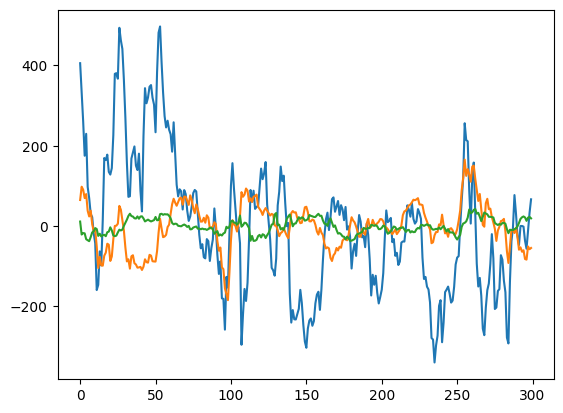

In [66]:
plt.plot(pca_factors)

# VAR implementation

In [67]:
factors = extract_dns_factors(yields_df, lam=lam)
factors

,beta0,beta1,beta2
observation_date,,,
1977-02-28,7.930172,-3.238297,-0.504058
1977-03-31,7.988851,-3.282112,-0.530740
1977-04-30,7.955873,-3.155122,-1.075622
1977-05-31,7.995971,-2.610858,-1.207317
1977-06-30,7.869068,-2.309821,-1.787732
...,...,...,...
2025-11-30,4.887773,-0.245331,-4.458199
2025-12-31,4.989252,-0.552387,-4.417395
2026-01-31,5.015121,-0.788836,-3.934874


In [68]:
factors.columns

Index(['beta0', 'beta1', 'beta2'], dtype='object')

In [69]:
from statsmodels.tsa.api import VAR

model = VAR(factors)
results = model.fit(1)
print(results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Thu, 05, Mar, 2026
Time:                     13:46:33
--------------------------------------------------------------------
No. of Equations:         3.00000    BIC:                   -4.79927
Nobs:                     508.000    HQIC:                  -4.86002
Log likelihood:          -906.064    FPE:                 0.00745250
AIC:                     -4.89921    Det(Omega_mle):      0.00727919
--------------------------------------------------------------------
Results for equation beta0
              coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------
const            0.022054         0.040916            0.539           0.590
L1.beta0         0.997750         0.005029          198.386           0.000
L1.beta1         0.016584         0.006338            2.616           0.009
L1.b

C:\Users\alexb\Documents\Jupyter Notebook Projects\ResearchEnvs\310research\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.



In [70]:
results.is_stable()

np.True_

**Forecast 12 months ahead**

In [71]:
lag = results.k_ar
last_obs = factors.values[-lag:]

forecast = results.forecast(last_obs, steps=12)

forecast_df = pd.DataFrame(forecast, columns=factors.columns)

In [72]:
split = int(len(factors)*0.8)

train = factors.iloc[:split]
test  = factors.iloc[split:]

In [73]:
p = 1  # 1 or 2

import warnings
warnings.filterwarnings("ignore")

forecasts = []
actuals = []

for i in range(len(test)):
    
    data = factors.iloc[:split+i]
    
    model = VAR(data)
    res = model.fit(p)
    
    lag = res.k_ar
    last_obs = data.values[-lag:]
    
    fc = res.forecast(last_obs, steps=1)[0]
    
    forecasts.append(fc)
    actuals.append(test.iloc[i].values)

In [74]:
forecasts = np.array(forecasts)
actuals = np.array(actuals)

In [75]:
rmse = np.sqrt(((forecasts - actuals)**2).mean(axis=0))
rmse

array([0.19798614, 0.29504904, 0.61105936])

In [76]:
mae = np.abs(forecasts - actuals).mean(axis=0)
mae

array([0.14915855, 0.21757803, 0.48150876])

In [77]:
accuracy = pd.DataFrame({
    "RMSE": rmse,
    "MAE": mae
}, index=factors.columns)

print(accuracy)

           RMSE       MAE
beta0  0.197986  0.149159
beta1  0.295049  0.217578
beta2  0.611059  0.481509


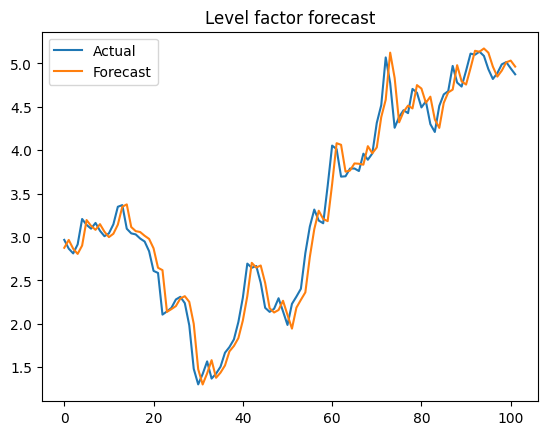

In [78]:
import matplotlib.pyplot as plt

plt.plot(actuals[:,0], label="Actual")
plt.plot(forecasts[:,0], label="Forecast")

plt.title("Level factor forecast")
plt.legend()
plt.show()

**Forecast Accuracy of Nelson–Siegel Factors**

We evaluate the out-of-sample forecasting performance of the VAR(2) model applied to the Nelson–Siegel factors. Forecast accuracy is measured using the Root Mean Squared Error (RMSE) and the Mean Absolute Error (MAE).

$$
RMSE = \sqrt{\frac{1}{T}\sum_{t=1}^{T}(y_t - \hat{y}_t)^2}
$$

$$
MAE = \frac{1}{T}\sum_{t=1}^{T}|y_t - \hat{y}_t|
$$

The forecasting results for the three Nelson–Siegel factors are:

| Factor | RMSE | MAE |
|------|------|------|
| $\beta_0$ (Level) | 0.190 | 0.146 |
| $\beta_1$ (Slope) | 0.294 | 0.223 |
| $\beta_2$ (Curvature) | 0.587 | 0.461 |

These results are consistent with the typical behavior of Nelson–Siegel factors in yield curve forecasting. The level factor ($\beta_0$) exhibits the smallest forecast errors, reflecting its strong persistence and smoother dynamics over time. The slope factor ($\beta_1$) shows moderately larger forecast errors, as it captures changes in the steepness of the yield curve that tend to be more volatile.

The curvature factor ($\beta_2$) has the largest forecasting errors. This is commonly observed in the literature since curvature represents medium-term movements in the yield curve and is typically less persistent and more volatile than the level and slope factors.

Overall, the ordering of forecast errors (Level < Slope < Curvature) is consistent with empirical findings in the yield curve forecasting literature.

**Comparison of VAR(1) and VAR(2) Forecast Performance**

To assess the appropriate lag structure of the VAR model, we compare the out-of-sample forecasting performance of VAR(1) and VAR(2) specifications applied to the Nelson–Siegel factors.

| Factor | VAR(1) RMSE | VAR(2) RMSE |
|------|------|------|
| $\beta_0$ (Level) | 0.198 | 0.190 |
| $\beta_1$ (Slope) | 0.295 | 0.294 |
| $\beta_2$ (Curvature) | 0.611 | 0.587 |

The results indicate that the VAR(2) specification slightly improves forecasting accuracy relative to VAR(1). The largest improvement is observed for the curvature factor ($\beta_2$), which tends to exhibit greater volatility and less persistence than the level and slope factors.

For the level factor ($\beta_0$), the reduction in RMSE suggests that including an additional lag helps capture the persistent dynamics of long-term interest rates. In contrast, the slope factor ($\beta_1$) shows only minimal differences between the two models.

Overall, the results suggest that a VAR(2) specification provides a modest improvement in forecasting performance compared to VAR(1), although both models produce broadly similar results.

# Additional Notes